In [1]:
#Import all the neccessary libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

customer = pd.read_excel(r"C:\Users\PREETHI\OneDrive\Desktop\Hospital_Analytics\Datasets\Zomato  Order Data.xlsx", sheet_name="Customer")
restaurants = pd.read_excel(r"C:\Users\PREETHI\OneDrive\Desktop\Hospital_Analytics\Datasets\Zomato  Order Data.xlsx", sheet_name="Restaurants")
orders = pd.read_excel(r"C:\Users\PREETHI\OneDrive\Desktop\Hospital_Analytics\Datasets\Zomato  Order Data.xlsx", sheet_name="Orders")

In [3]:
#print top 5 rows of each sheet

customer.head()

,customer_id,customer_name,city,signup_time,acquisition_channel
0,C00002,Rohan Agarwal,Delhi,2024-05-06 23:10:00,Organic
1,C00003,Priya Verma,Hyderabad,2025-10-13 12:21:00,Instagram Ads
2,C00004,Neha Singh,Mumbai,2024-02-06 15:08:00,WhatsApp Campaign
3,C00005,Amit Kumar,Noida,2024-11-08 03:13:00,Referral
4,C00006,Rohan Agarwal,Chennai,2024-06-04 19:28:00,Instagram Ads


In [4]:
restaurants.head()

,restaurant_id,restaurant_name,cuisine,city,avg_rating
0,R0001,Chaayos,Fast Food,Hyderabad,4.5
1,R0002,Chaayos,North Indian,Gurugram,4.5
2,R0003,Barbeque Nation,Pizza,Chennai,4.1
3,R0004,KFC,Pizza,Pune,4.4
4,R0005,Pizza Hut,North Indian,Mumbai,5.0


In [5]:
orders.head()

,order_id,customer_id,restaurant_id,order_timestamp,order_amount,discount_amount,delivery_fee,payment_mode,order_status
0,O000001,C03175,R0115,2025-09-28 20:55:00,1079.36,107.94,39,Cash,Refunded
1,O000002,C02432,R0077,2024-02-13 22:43:00,1499.63,149.96,42,Card,Delivered
2,O000003,C01133,R0131,2024-03-07 19:20:00,597.18,59.72,22,Cash,Delivered
3,O000004,C04813,R0109,2025-01-27 14:21:00,1257.48,125.75,53,Wallet,Delivered
4,O000005,C04948,R0001,2024-10-25 22:43:00,1010.57,0.00,28,Wallet,Delivered


In [ ]:
#Performing techinical eda for ensuring there's no duplicates , missing values , and ensuring the data quality for the further analysis 

In [12]:
#First step  

print(customer.shape)
print(restaurants.shape)
print(orders.shape)   #to understand the Size of the datasets

(4999, 5)
(200, 5)
(50000, 9)


In [13]:
#checking the datatypes 

customer.dtypes
restaurants.dtypes
orders.dtypes

order_id                   object
customer_id                object
restaurant_id              object
order_timestamp    datetime64[ns]
order_amount              float64
discount_amount           float64
delivery_fee                int64
payment_mode               object
order_status               object
dtype: object

In [15]:
#Descriptive Statistics (Numerical Columns)

orders.describe()

,order_timestamp,order_amount,discount_amount,delivery_fee
count,50000,50000.000000,50000.000000,50000.000000
mean,2025-03-02 01:22:35.259600128,899.129451,36.276467,40.013940
min,2024-01-01 12:08:00,200.450000,0.000000,20.000000
25%,2024-08-01 20:15:30,574.345000,0.000000,30.000000
50%,2025-02-28 20:43:30,896.895000,0.000000,40.000000
75%,2025-10-02 13:03:00,1224.202500,74.182500,50.000000
max,2026-04-30 22:51:00,1598.970000,159.680000,60.000000
std,NaN,376.686808,50.260681,11.825142


In [16]:
#Step 4: Categorical Summary

customer.describe(include='object')

restaurants.describe(include='object')

orders.describe(include='object')

,order_id,customer_id,restaurant_id,payment_mode,order_status
count,50000,50000,50000,50000,50000
unique,50000,5000,200,4,3
top,O000001,C02951,R0072,UPI,Delivered
freq,1,24,288,24900,29837


In [19]:
#check unique values in each dataset

customer.nunique()

customer_id            4999
customer_name             8
city                      8
signup_time            4988
acquisition_channel       5
dtype: int64

In [20]:
restaurants.nunique()

restaurant_id      200
restaurant_name     12
cuisine              6
city                 8
avg_rating          16
dtype: int64

In [21]:
orders.nunique()

order_id           50000
customer_id         5000
restaurant_id        200
order_timestamp    46585
order_amount       41641
discount_amount    10417
delivery_fee          41
payment_mode           4
order_status           3
dtype: int64

In [23]:
#Checking frequency distibution 

customer['city'].value_counts()


city
Noida        666
Pune         644
Bengaluru    619
Chennai      618
Hyderabad    615
Gurugram     613
Delhi        612
Mumbai       612
Name: count, dtype: int64

In [24]:
customer['acquisition_channel'].value_counts()

acquisition_channel
Instagram Ads        1028
Referral             1001
WhatsApp Campaign     991
Google Ads            991
Organic               988
Name: count, dtype: int64

In [25]:
restaurants['city'].value_counts()

city
Chennai      32
Hyderabad    27
Pune         27
Noida        26
Delhi        26
Gurugram     22
Mumbai       20
Bengaluru    20
Name: count, dtype: int64

In [26]:
restaurants['cuisine'].value_counts()

cuisine
North Indian    40
Fast Food       37
Pizza           37
Healthy         30
Cafe            30
Biryani         26
Name: count, dtype: int64

In [27]:
orders['order_status'].value_counts()

order_status
Delivered    29837
Cancelled    10095
Refunded     10068
Name: count, dtype: int64

In [28]:
#Checking dupliactes 

customer.duplicated().sum()

0

In [29]:
restaurants.duplicated().sum()

0

In [30]:
orders.duplicated().sum()

0

In [ ]:
#Check missing values 

In [31]:
print("missing values in customer", customer.isnull().sum())
print("missing values in restaurants", restaurants.isnull().sum())
print("missing values in orders", orders.isnull().sum())

missing values in customer customer_id            0
customer_name          0
city                   0
signup_time            0
acquisition_channel    0
dtype: int64
missing values in restaurants restaurant_id      0
restaurant_name    0
cuisine            0
city               0
avg_rating         0
dtype: int64
missing values in orders order_id           0
customer_id        0
restaurant_id      0
order_timestamp    0
order_amount       0
discount_amount    0
delivery_fee       0
payment_mode       0
order_status       0
dtype: int64


In [34]:
#Outlier Detection (Numerical Columns) 

customer.columns  #checking numerical columns to perfrom outlier detections

Index(['customer_id', 'customer_name', 'city', 'signup_time',
       'acquisition_channel'],
      dtype='object')

In [35]:
orders.columns

Index(['order_id', 'customer_id', 'restaurant_id', 'order_timestamp',
       'order_amount', 'discount_amount', 'delivery_fee', 'payment_mode',
       'order_status'],
      dtype='object')

In [37]:
restaurants.columns

Index(['restaurant_id', 'restaurant_name', 'cuisine', 'city', 'avg_rating'], dtype='object')

In [38]:
#Perfroming outlier 

Q1 = orders['order_amount'].quantile(0.25)
Q3 = orders['order_amount'].quantile(0.75)

IQR = Q3 - Q1 

upper_limit= Q1 - 1.5 * IQR 
lower_limit= Q3 + 1.5 * IQR 

print("upper limit", upper_limit)
print("lower limit", lower_limit)

upper limit -400.4412500000001
lower limit 2198.9887500000004


In [40]:
#Now verify it 

orders['order_amount'].describe()

count    50000.000000
mean       899.129451
std        376.686808
min        200.450000
25%        574.345000
50%        896.895000
75%       1224.202500
max       1598.970000
Name: order_amount, dtype: float64

In [45]:
Q1 = orders['order_amount'].quantile(0.25)
Q3 = orders['order_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = orders[
    (orders['order_amount'] < lower_limit) |
    (orders['order_amount'] > upper_limit)
]

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of outliers:", outliers.shape[0])

Lower Limit: -400.4412500000001
Upper Limit: 2198.9887500000004
Number of outliers: 0


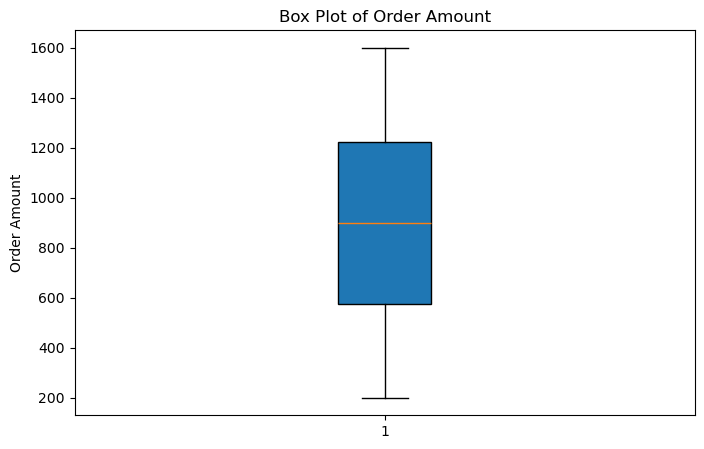

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(
    orders['order_amount'],
    vert=True,
    patch_artist=True
)

plt.title("Box Plot of Order Amount")
plt.ylabel("Order Amount")

plt.show()

In [54]:
Q1 = orders['discount_amount'].quantile(0.25)
Q3 = orders['discount_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = orders[ (orders['discount_amount'] < lower_limit) |  (orders['discount_amount'] > upper_limit) ]

print("Number of Outliers:", outliers.shape[0])

Lower Limit: -111.27375
Upper Limit: 185.45625
Number of Outliers: 0


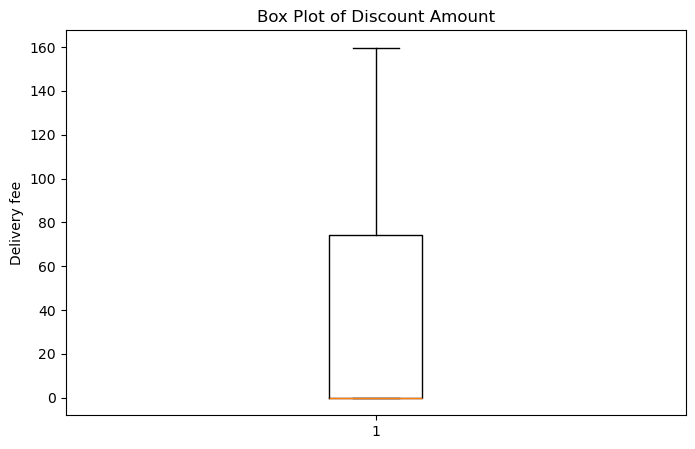

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(
    orders['discount_amount']
)

plt.title("Box Plot of Discount Amount")
plt.ylabel("Delivery fee")

plt.show()

In [ ]:
#oulier for delivery fee

In [57]:
Q1 = orders['delivery_fee'].quantile(0.25)
Q3 = orders['delivery_fee'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = orders[ (orders['delivery_fee'] < lower_limit) |  (orders['delivery_fee'] > upper_limit) ]

print("Number of Outliers:", outliers.shape[0])

Lower Limit: 0.0
Upper Limit: 80.0
Number of Outliers: 0


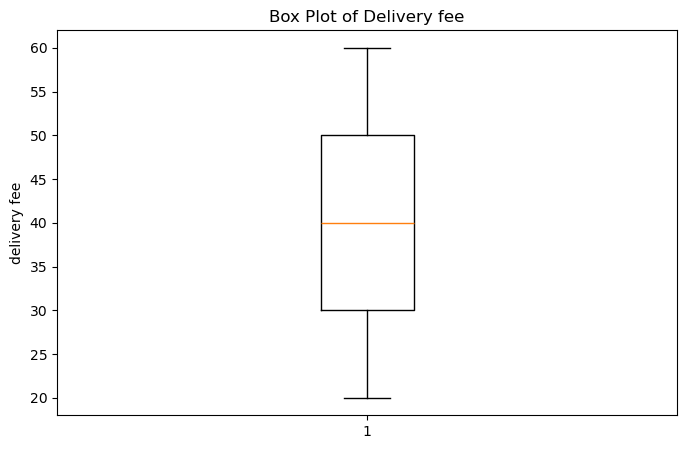

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(
    orders['delivery_fee']
)

plt.title("Box Plot of Delivery fee")
plt.ylabel("delivery fee")

plt.show()

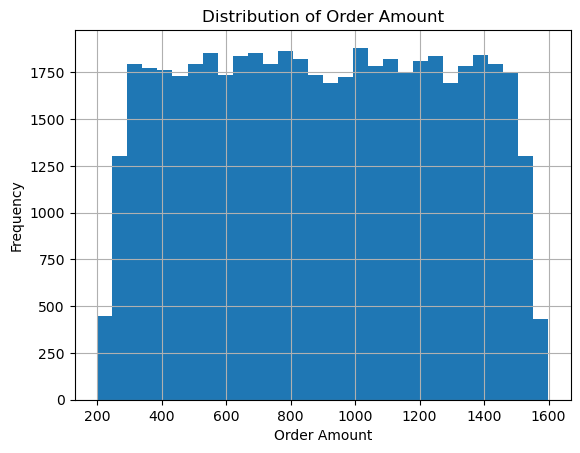

In [60]:
#Performing Distribution analysis  to check whether it is distibuted properly or not

import matplotlib.pyplot as plt

orders['order_amount'].hist(bins=30)
plt.title("Distribution of Order Amount")
plt.xlabel("Order Amount")
plt.ylabel("Frequency")
plt.show()

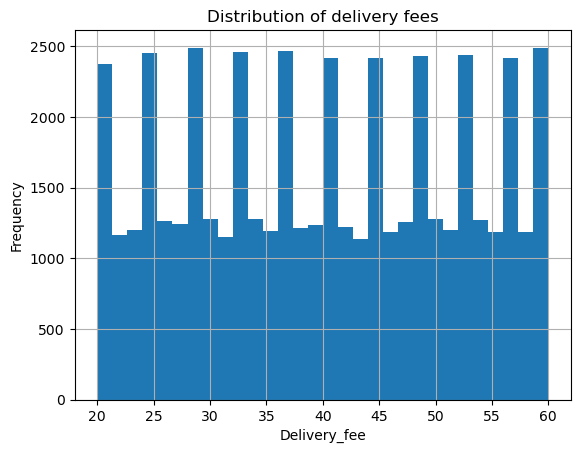

In [61]:
import matplotlib.pyplot as plt

orders['delivery_fee'].hist(bins=30)
plt.title("Distribution of delivery fees")
plt.xlabel("Delivery_fee")
plt.ylabel("Frequency")
plt.show()

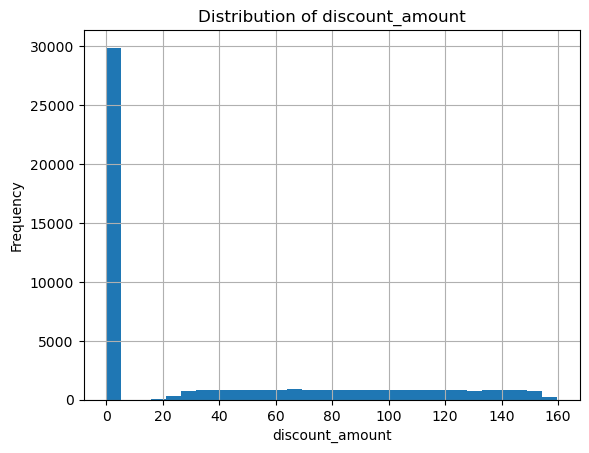

In [62]:
import matplotlib.pyplot as plt

orders['discount_amount'].hist(bins=30)
plt.title("Distribution of discount_amount")
plt.xlabel("discount_amount")
plt.ylabel("Frequency")
plt.show()

In [63]:
#correlation 

corr = orders.select_dtypes(include='number').corr()

corr

,order_amount,discount_amount,delivery_fee
order_amount,1.000000,0.306533,0.003899
discount_amount,0.306533,1.000000,0.002067
delivery_fee,0.003899,0.002067,1.000000


In [ ]:
#    **************************** BUSSINESS EDA *****************************************************

In [65]:
orders.head(5)

,order_id,customer_id,restaurant_id,order_timestamp,order_amount,discount_amount,delivery_fee,payment_mode,order_status
0,O000001,C03175,R0115,2025-09-28 20:55:00,1079.36,107.94,39,Cash,Refunded
1,O000002,C02432,R0077,2024-02-13 22:43:00,1499.63,149.96,42,Card,Delivered
2,O000003,C01133,R0131,2024-03-07 19:20:00,597.18,59.72,22,Cash,Delivered
3,O000004,C04813,R0109,2025-01-27 14:21:00,1257.48,125.75,53,Wallet,Delivered
4,O000005,C04948,R0001,2024-10-25 22:43:00,1010.57,0.00,28,Wallet,Delivered


In [ ]:
#Performing feature engineering 

In [87]:
orders = pd.read_excel(r"C:\Users\PREETHI\OneDrive\Desktop\Hospital_Analytics\Datasets\Zomato  Order Data.xlsx", sheet_name="Orders")

In [88]:
orders.head()

,order_id,customer_id,restaurant_id,order_timestamp,order_amount,discount_amount,delivery_fee,payment_mode,order_status
0,O000001,C03175,R0115,2025-09-28 20:55:00,1079.36,107.94,39,Cash,Refunded
1,O000002,C02432,R0077,2024-02-13 22:43:00,1499.63,149.96,42,Card,Delivered
2,O000003,C01133,R0131,2024-03-07 19:20:00,597.18,59.72,22,Cash,Delivered
3,O000004,C04813,R0109,2025-01-27 14:21:00,1257.48,125.75,53,Wallet,Delivered
4,O000005,C04948,R0001,2024-10-25 22:43:00,1010.57,0.00,28,Wallet,Delivered


In [89]:
orders['revenue']= orders['order_amount']+orders['delivery_fee']-orders['discount_amount']

In [90]:
orders['revenue']

0        1010.42
1        1391.67
2         559.46
3        1184.73
4        1038.57
          ...   
49995     421.31
49996     532.84
49997     920.67
49998     758.99
49999    1125.95
Name: revenue, Length: 50000, dtype: float64

In [91]:
orders['revenue'].sum()

45143346.21

In [92]:
orders['year'] = orders['order_timestamp'].dt.year

In [93]:
#Yearly revenue trend of zomato

yearly_revenue = (
    orders.groupby('year')['revenue']
          .sum()
          .reset_index()
)

print(yearly_revenue)

   year      revenue
0  2024  19403834.72
1  2025  19407831.84
2  2026   6331679.65


In [96]:
#Creating month column 

orders['month'] = orders['order_timestamp'].dt.month_name()

In [98]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

orders['month'] = pd.Categorical(
    orders['month'],
    categories=month_order,
    ordered=True
)

In [101]:
monthly_revenue_2024 = (
    orders[orders['year'] == 2024]
    .groupby('month')['revenue']
    .sum()
    .reset_index()
)

print(monthly_revenue_2024)

        month     revenue
0     January  1651612.43
1    February  1552236.71
2       March  1631600.76
3       April  1660010.65
4         May  1603404.02
5        June  1602512.12
6        July  1579632.27
7      August  1651341.63
8   September  1576995.84
9     October  1669487.36
10   November  1608451.62
11   December  1616549.31


C:\Users\PREETHI\AppData\Local\Temp\ipykernel_24772\1353369324.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('month')['revenue']


In [109]:
monthly_revenue_2025 = (
    orders[orders['year'] == 2025]
    .groupby('month')['revenue']
    .sum()
    .reset_index()
)

print(monthly_revenue_2025)

        month     revenue
0     January  1704267.49
1    February  1470494.16
2       March  1625722.26
3       April  1530395.21
4         May  1661249.84
5        June  1583708.51
6        July  1630870.49
7      August  1588203.56
8   September  1588096.82
9     October  1706626.06
10   November  1608273.11
11   December  1709924.33


C:\Users\PREETHI\AppData\Local\Temp\ipykernel_24772\1252911371.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('month')['revenue']


In [102]:
monthly_revenue_comparison = (
    orders[orders['year'].isin([2024, 2025])]
    .groupby(['month', 'year'])['revenue']
    .sum()
    .unstack()
    .reindex([
        'January', 'February', 'March', 'April',
        'May', 'June', 'July', 'August',
        'September', 'October', 'November', 'December'
    ])
)

print(monthly_revenue_comparison)

year             2024        2025
month                            
January    1651612.43  1704267.49
February   1552236.71  1470494.16
March      1631600.76  1625722.26
April      1660010.65  1530395.21
May        1603404.02  1661249.84
June       1602512.12  1583708.51
July       1579632.27  1630870.49
August     1651341.63  1588203.56
September  1576995.84  1588096.82
October    1669487.36  1706626.06
November   1608451.62  1608273.11
December   1616549.31  1709924.33


C:\Users\PREETHI\AppData\Local\Temp\ipykernel_24772\905770564.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['month', 'year'])['revenue']


In [ ]:
#Revenue fluctuated across the months in both years, indicating that monthly revenue was not consistent.
#January revenue increased from 1.65M (2024) to 1.70M (2025).
#February recorded lower revenue in both years, decreasing from 1.55M to 1.47M, making it one of the weakest-performing months.
#March remained almost unchanged (1.63M in 2024 vs 1.63M in 2025), showing stable performance.
#April experienced a noticeable decline from 1.66M to 1.53M.
#May improved from 1.60M to 1.66M.
#June remained relatively stable, with only a slight decrease (1.60M to 1.58M).
#July showed an increase from 1.58M to 1.63M.
#August declined from 1.65M to 1.59M.
#September remained almost unchanged at around 1.58M.
#October was one of the strongest-performing months in both years, increasing from 1.67M to 1.71M.
#November remained virtually identical at approximately 1.61M.
#December recorded a significant increase from 1.62M to 1.71M.

In [103]:
#2026 (RUNNING YEAR) 

orders[orders['year'] == 2026]['order_timestamp'].agg(['min', 'max'])

min   2026-01-01 12:16:00
max   2026-04-30 22:51:00
Name: order_timestamp, dtype: datetime64[ns]

In [104]:
monthly_revenue_2026 = (
    orders[orders['year'] == 2026]
    .groupby('month')['revenue']
    .sum()
    .reset_index()
)

print(monthly_revenue_2026)

        month     revenue
0     January  1640399.77
1    February  1525984.39
2       March  1615573.41
3       April  1549722.08
4         May        0.00
5        June        0.00
6        July        0.00
7      August        0.00
8   September        0.00
9     October        0.00
10   November        0.00
11   December        0.00


C:\Users\PREETHI\AppData\Local\Temp\ipykernel_24772\3899379989.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('month')['revenue']


In [ ]:
# Observation:
# - The dataset contains revenue data only from January to April 2026,
#   indicating that 2026 is a partial (running) year.
# - January recorded the highest revenue at 1,640,399.77.
# - Revenue declined to 1,525,984.39 in February, the lowest among the available months.
# - Revenue recovered to 1,615,573.41 in March.
# - April showed another decline to 1,549,722.08.

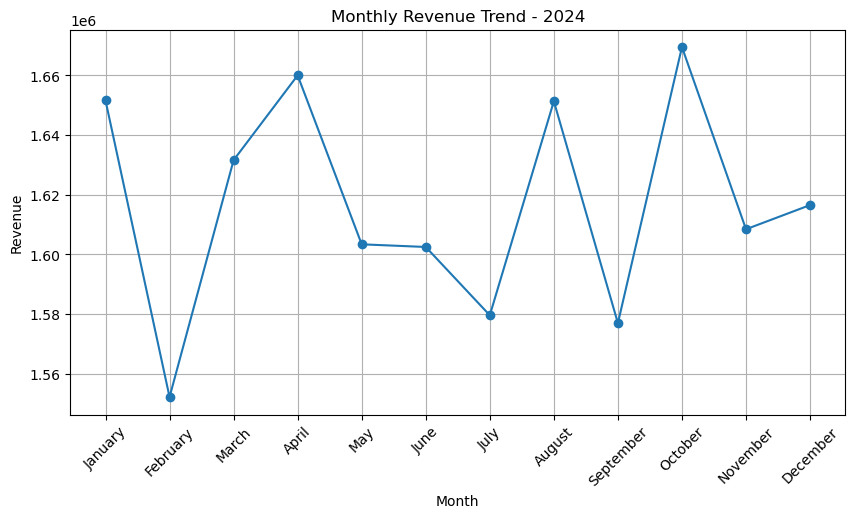

In [105]:
plt.figure(figsize=(10,5))
plt.plot(
    monthly_revenue_2024['month'],
    monthly_revenue_2024['revenue'],
    marker='o'
)
plt.title("Monthly Revenue Trend - 2024")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

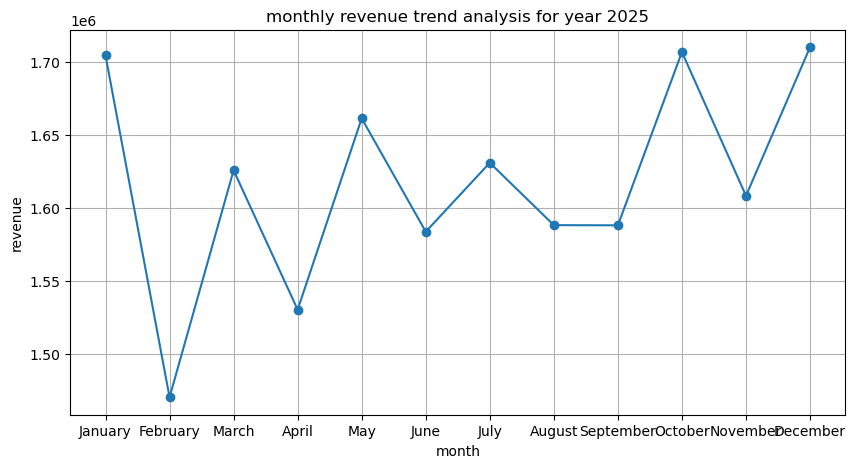

In [115]:
plt.figure(figsize=(10,5))

plt.plot( 
      monthly_revenue_2025['month'],
      monthly_revenue_2025['revenue'],
      marker='o'
      )

plt.title("monthly revenue trend analysis for year 2025")
plt.xlabel('month')
plt.ylabel('revenue')
plt.axis('on')
plt.grid(True)
plt.show()


C:\Users\PREETHI\AppData\Local\Temp\ipykernel_24772\3026645214.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['year', 'month'])['revenue']


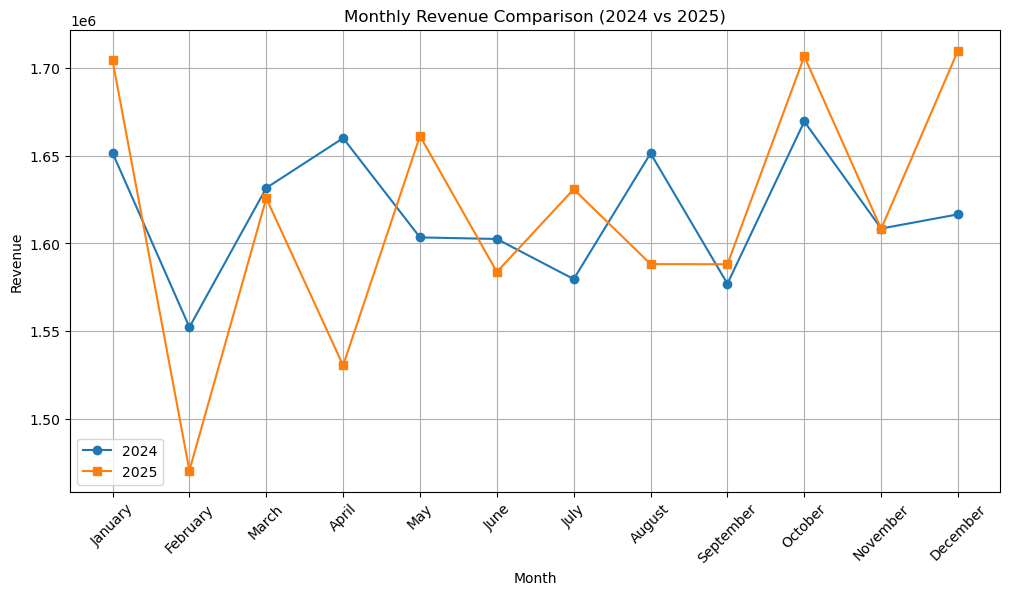

In [118]:
import matplotlib.pyplot as plt

# Monthly revenue for 2024 and 2025
monthly_revenue = (
    orders[orders['year'].isin([2024, 2025])]
    .groupby(['year', 'month'])['revenue']
    .sum()
    .unstack(level=0)
    .reindex([
        'January', 'February', 'March', 'April',
        'May', 'June', 'July', 'August',
        'September', 'October', 'November', 'December'
    ])
)

# Plot
plt.figure(figsize=(12,6))

plt.plot(monthly_revenue.index,
         monthly_revenue[2024],
         marker='o',
         label='2024')

plt.plot(monthly_revenue.index,
         monthly_revenue[2025],
         marker='s',
         label='2025')

plt.title("Monthly Revenue Comparison (2024 vs 2025)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [119]:
#BUSSINESS EDA 2 :  FOR RESTUARANTS UNDERPERFORMING 

In [120]:
restaurants.head(5)

,restaurant_id,restaurant_name,cuisine,city,avg_rating
0,R0001,Chaayos,Fast Food,Hyderabad,4.5
1,R0002,Chaayos,North Indian,Gurugram,4.5
2,R0003,Barbeque Nation,Pizza,Chennai,4.1
3,R0004,KFC,Pizza,Pune,4.4
4,R0005,Pizza Hut,North Indian,Mumbai,5.0


In [121]:
#Total no of restaurants in each city 

restaurants['city'].value_counts()

city
Chennai      32
Hyderabad    27
Pune         27
Noida        26
Delhi        26
Gurugram     22
Mumbai       20
Bengaluru    20
Name: count, dtype: int64

In [122]:
restaurant_orders = orders.merge(
    restaurants,
    on='restaurant_id',
    how='left'
)

In [123]:
restaurants['city'].count()

200

In [124]:
#Total revenue 

restaurant_orders['revenue'].sum()

45143346.21

In [125]:
restaurant_orders['order_id'].count()  #Total orders

50000

In [126]:
restaurant_orders.groupby('restaurant_name')['revenue'].sum()

restaurant_name
Barbeque Nation    4563701.78
Behrouz Biryani    4243659.88
Biryani By Kilo    4294379.02
Burger King        4530804.29
Chaayos            4290302.98
Domino's Pizza     3971441.39
Haldiram's         4124863.17
KFC                3449395.57
McDonald's         2935792.89
Pizza Hut          2907281.15
Starbucks          3576543.53
Subway             2255180.56
Name: revenue, dtype: float64

In [127]:
restaurant_orders.groupby('restaurant_name')['order_id'].count()

restaurant_name
Barbeque Nation    5034
Behrouz Biryani    4657
Biryani By Kilo    4794
Burger King        5027
Chaayos            4733
Domino's Pizza     4395
Haldiram's         4561
KFC                3792
McDonald's         3292
Pizza Hut          3236
Starbucks          3970
Subway             2509
Name: order_id, dtype: int64

In [128]:
#Average revenue per Restaurant 

restaurant_orders.groupby('restaurant_name')['revenue'].mean()

restaurant_name
Barbeque Nation    906.575642
Behrouz Biryani    911.243264
Biryani By Kilo    895.782023
Burger King        901.293871
Chaayos            906.465874
Domino's Pizza     903.627165
Haldiram's         904.376928
KFC                909.650730
McDonald's         891.796139
Pizza Hut          898.418155
Starbucks          900.892577
Subway             898.836413
Name: revenue, dtype: float64

In [130]:
restaurant_orders['order_timestamp'] = pd.to_datetime(restaurant_orders['order_timestamp'])

restaurant_orders['Year'] = restaurant_orders['order_timestamp'].dt.year

In [132]:
yearly_restaurant_revenue = restaurant_orders.pivot_table(
    index='restaurant_name',
    columns='Year',
    values='order_amount',
    aggfunc='sum',
    fill_value=0
)

yearly_restaurant_revenue

Year,2024,2025,2026
restaurant_name,,,
Barbeque Nation,1916057.72,1995239.94,631698.04
Behrouz Biryani,1801036.18,1836205.76,590777.46
Biryani By Kilo,1849931.45,1810107.44,613568.03
Burger King,1969998.00,1921521.19,624277.07
Chaayos,1834737.67,1833606.95,605895.31
Domino's Pizza,1681845.08,1714993.88,557054.50
Haldiram's,1790181.85,1707468.32,612572.09
KFC,1479717.81,1457249.23,500806.05
McDonald's,1262709.34,1265141.61,393529.07


In [ ]:
##Barbeque Nation generated the highest revenue in both years and showed a slight increase in 2025.
#Burger King, Biryani By Kilo, Haldiram's, and KFC experienced a slight decline in revenue from 2024 to 2025.
#Domino's Pizza, Starbucks, Pizza Hut, McDonald's, and Behrouz Biryani showed a small increase in revenue during 2025.
#Subway consistently recorded the lowest revenue among all restaurants in both years.
#Overall, there is no significant year-over-year decline in restaurant revenue, indicating that restaurant performance is generally stable. However, a few restaurants exhibit declining trends and may require further investigation.

In [134]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_restaurant_revenue_2024 = (
    restaurant_orders[restaurant_orders['Year'] == 2024]
    .pivot_table(
        index='restaurant_name',
        columns='Month',
        values='order_amount',
        aggfunc='sum',
        fill_value=0
    )
)

monthly_restaurant_revenue_2024 = monthly_restaurant_revenue_2024.reindex(columns=month_order)

monthly_restaurant_revenue_2024 

Month,January,February,March,April,May,June,July,August,September,October,November,December
restaurant_name,,,,,,,,,,,,
Barbeque Nation,164732.04,169084.03,169618.44,133793.76,157047.23,139302.76,158373.67,170985.55,161478.62,174491.78,151695.39,165454.45
Behrouz Biryani,144689.86,136969.17,147698.59,160284.35,159136.98,148959.74,171690.58,149139.14,154603.80,153627.67,140178.06,134058.24
Biryani By Kilo,175950.84,162466.89,152833.21,165304.31,140200.35,154929.55,142056.32,153409.79,130790.04,156720.79,152506.38,162762.98
Burger King,174290.88,142349.95,162136.10,167538.15,165767.02,175657.51,154771.22,160554.15,176743.23,175058.52,168070.48,147060.79
Chaayos,142905.12,140925.73,166448.06,150941.50,148697.26,134746.87,161536.65,186474.07,144008.09,154071.35,159347.34,144635.63
Domino's Pizza,133013.90,126405.20,147948.10,167485.69,140270.72,148814.38,134605.06,145297.56,127573.74,125744.65,132037.45,152648.63
Haldiram's,151171.37,138143.18,147340.76,168207.46,143447.50,148682.22,144379.65,147656.04,134443.60,162542.09,150534.18,153633.80
KFC,118943.28,114671.03,121865.56,147244.19,110066.68,137783.93,113559.18,115003.17,135945.12,121475.68,119029.67,124130.32
McDonald's,127129.53,90703.86,104081.41,85206.64,120355.63,93050.32,112544.96,104368.87,99503.36,103448.52,120598.14,101718.10


In [136]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_restaurant_revenue_2024 = (
    restaurant_orders[restaurant_orders['Year'] == 2025]
    .pivot_table(
        index='restaurant_name',
        columns='Month',
        values='order_amount',
        aggfunc='sum',
        fill_value=0
    )
)

monthly_restaurant_revenue_2025 = monthly_restaurant_revenue_2024.reindex(columns=month_order)

monthly_restaurant_revenue_2025

Month,January,February,March,April,May,June,July,August,September,October,November,December
restaurant_name,,,,,,,,,,,,
Barbeque Nation,194767.00,140854.21,161052.18,158617.09,172657.35,155254.99,147862.37,157482.10,194692.73,162481.79,177748.29,171769.84
Behrouz Biryani,180013.62,151821.42,136986.17,152991.89,148566.58,127064.38,154285.12,151534.32,128963.19,196075.61,147886.90,160016.56
Biryani By Kilo,145079.81,134262.40,165982.95,146772.90,144835.04,150720.36,181643.03,148163.19,127648.09,167984.35,135963.30,161052.02
Burger King,169719.07,133355.18,152728.40,145219.83,173573.40,156286.54,164090.45,158124.49,150424.27,164304.71,183405.84,170289.01
Chaayos,160155.69,123214.34,151477.71,140226.74,159520.44,175535.60,146333.01,143808.37,153222.23,152582.32,150344.45,177186.05
Domino's Pizza,156757.93,118894.66,122630.46,141096.34,165292.54,167741.63,145618.52,133421.77,152008.53,138194.39,144578.95,128758.16
Haldiram's,157698.57,129252.08,164444.86,127775.92,145579.33,133319.83,140155.51,135451.15,145964.09,125319.51,126814.03,175693.44
KFC,121997.19,131187.55,131709.13,115704.26,108324.83,121017.38,113989.72,106130.06,107036.69,145586.01,132125.81,122440.60
McDonald's,106523.44,95507.68,113509.10,108709.92,118587.85,97562.80,97224.63,107651.85,103043.97,117623.95,93483.36,105713.06


In [137]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_restaurant_revenue_2024 = (
    restaurant_orders[restaurant_orders['Year'] == 2026]
    .pivot_table(
        index='restaurant_name',
        columns='Month',
        values='order_amount',
        aggfunc='sum',
        fill_value=0
    )
)

monthly_restaurant_revenue_2026 = monthly_restaurant_revenue_2024.reindex(columns=month_order)

monthly_restaurant_revenue_2026

Month,January,February,March,April,May,June,July,August,September,October,November,December
restaurant_name,,,,,,,,,,,,
Barbeque Nation,152976.55,140829.07,175867.90,162024.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Behrouz Biryani,156109.01,146653.08,138980.55,149034.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Biryani By Kilo,167123.05,150064.38,146867.72,149512.88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Burger King,166576.77,135308.12,172479.15,149913.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Chaayos,143709.87,128915.58,170514.45,162755.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Domino's Pizza,143065.64,128922.13,158889.18,126177.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Haldiram's,176156.53,142559.49,164459.79,129396.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KFC,128979.37,133303.21,123359.90,115163.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
McDonald's,106299.78,96627.71,98760.91,91840.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [138]:
restaurant_orders_pivot = (
    restaurant_orders
    .pivot_table(
        index='restaurant_name',
        columns='Year',
        values='order_id',
        aggfunc='count',
        fill_value=0
    )
)

restaurant_orders_pivot

Year,2024,2025,2026
restaurant_name,,,
Barbeque Nation,2124,2218,692
Behrouz Biryani,1997,2020,640
Biryani By Kilo,2058,2044,692
Burger King,2176,2149,702
Chaayos,2028,2039,666
Domino's Pizza,1875,1891,629
Haldiram's,1972,1892,697
KFC,1638,1597,557
McDonald's,1426,1410,456


In [139]:
restaurant_orders_pivot = (
    restaurant_orders
    .pivot_table(
        index='restaurant_name',
        columns='Year',
        values='avg_rating',
        aggfunc='mean',
        fill_value=0
    )
)

restaurant_orders_pivot

Year,2024,2025,2026
restaurant_name,,,
Barbeque Nation,4.356121,4.341885,4.327457
Behrouz Biryani,4.328092,4.308267,4.321875
Biryani By Kilo,4.053499,4.059687,4.060260
Burger King,4.318612,4.303955,4.301282
Chaayos,4.339152,4.341736,4.336036
Domino's Pizza,4.378293,4.366367,4.376948
Haldiram's,4.420183,4.413901,4.440172
KFC,4.098840,4.110770,4.119569
McDonald's,4.215358,4.189220,4.195614


In [142]:
#now load all the files to local files for the purpose of further analysis 

# Save cleaned datasets for further analysis

customer.to_csv(
    r"C:\Users\PREETHI\OneDrive\Desktop\cleaned_Customers.csv",
    index=False
)

orders.to_csv(
    r"C:\Users\PREETHI\OneDrive\Desktop\cleaned_Orders.csv",
    index=False
)

restaurants.to_csv(
    r"C:\Users\PREETHI\OneDrive\Desktop\cleaned_Restaurants.csv",
    index=False
)

KeyError: "None of [Index(['total_orders', 'total_revenue'], dtype='object')] are in the [columns]"